In [374]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
fs=10
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
plt.rcParams.update({'font.size': fs})

In [375]:
random_state = [12, 432, 5, 7543, 12343, 452, 325432435, 326, 436, 2435]
descriptor = 'ATMOMACCS_DECIMAL_v4'

In [376]:
class ShapAnalyser:
    def __init__(self, dataset: str, descriptor: str,  targets: list[str]):
        self.dataset = dataset
        self.targets = targets
        self.descriptor = descriptor
        self.feature_names = np.loadtxt(f'../data/{self.dataset}/descriptors/{self.descriptor}_feats.txt', dtype=str, delimiter='~')
        pass

    def load_shap(self) -> dict:
        shap_vals_all = {target: [] for target in self.targets}
        for target in self.targets:
            for seed in random_state:
                with open(f'../data/{self.dataset}/shap/shap_values_{self.descriptor}_{target}_{seed}.pkl', 'rb') as file:
                    shap_vals = pickle.load(file)
                    shap_vals_all[target].append(shap_vals)
        self.shap_vals_all: dict[list[np.ndarray]] = shap_vals_all
        return shap_vals_all

    def calc_mean_absolute_shaps(self):
        mean_absolute_shaps = pd.DataFrame()
        for target in self.targets:
            shapvals = self.shap_vals_all[target]
            mean_absolute_shap_vals: np.ndarray = np.zeros_like(shapvals[0][1])   

            for i, shap_seed in enumerate(shapvals):
                mean_absolute_shap_vals += np.mean(np.abs(shap_seed), axis=0)

            mean_absolute_shap_vals /= len(shapvals)
            mean_absolute_shaps[target] = mean_absolute_shap_vals

        mean_absolute_shaps.index = self.feature_names
        self.mean_absolute_shap_values = mean_absolute_shaps
        return mean_absolute_shaps
    
    def sort_features(self):
        features = {
            'Carbon number': [],
            'Oxygen number': [],
            'Functional fragments': [],
            'Carbon bond types': [],
            'Non-oxygen MACCS keys': []
            }
        functional_feature_names = []
        for f_name in self.feature_names:
            oxygen_matches = ['164', '159', '146', '140', 'O (bit', 'oxygen']
            #oxygen_matches = ['O (bit', 'oxygen']
            oxygen_matches  = [query in f_name for query in oxygen_matches]
            if any(oxygen_matches):
                features['Oxygen number'].append(f_name)
            elif 'MACCS' in f_name:
                features['Non-oxygen MACCS keys'].append(f_name)
            elif 'C (bit' in f_name or 'carbon' in f_name:
                features['Carbon number'].append(f_name)
            elif 'CH' in f_name or 'C=C' in f_name:
                print(f_name)
                features['Carbon bond types'].append(f_name)
            else:
                functional_feature_names.append(f_name)
                features['Functional fragments'].append(f_name)
        self.functional_feature_names = functional_feature_names
        self.feature_categories = features
        return features
    
    def sum_shap_vals_per_category(self):
        features = pd.DataFrame(columns=self.targets, index=self.feature_categories.keys())
        for target in self.targets:
            for category in features.index:
                feature_names = self.feature_categories[category]
                features[target].loc[category]= self.mean_absolute_shap_values[target].loc[feature_names].sum()
        self.shap_vals_categorized = features
        return features

In [377]:
wang_targets = ['log_p_sat', 'log_kwg', 'log_kwiomg']
Wang = ShapAnalyser('Wang', descriptor, wang_targets)
Wang.load_shap()
Wang.calc_mean_absolute_shaps()
Wang.sort_features()
Wang.sum_shap_vals_per_category()
df = Wang.shap_vals_categorized
cols = df.columns
for col in cols:
    df[f'{Wang.dataset}_{col}'] = df[col]
df = df.drop(columns=cols)
df

alkane CH
alkene CH
aromatic CH
C=C-C=O in non-aromatic ring
C=C (non-aromatic)


C:\Users\kuuli\AppData\Local\Temp\ipykernel_12476\4065991944.py:69: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  features[target].loc[category]= self.mean_absolute_shap_values[target].loc[feature_names].sum()
C:\Users\kuuli\AppData\Local\Te

,Wang_log_p_sat,Wang_log_kwg,Wang_log_kwiomg
Carbon number,0.786596,0.583673,0.829283
Oxygen number,1.072519,1.580477,1.277375
Functional fragments,0.638721,1.132378,0.626057
Carbon bond types,0.414357,0.680463,0.292942
Non-oxygen MACCS keys,6.121296,11.952113,5.755404


In [378]:
try:
    geckoq_targets = ['log_p_sat']
    geckoq = ShapAnalyser('GeckoQ', descriptor, geckoq_targets)
    geckoq.load_shap()
    geckoq.calc_mean_absolute_shaps()
    geckoq.sort_features()
    geckoq.sum_shap_vals_per_category()
except:
    print('Something went wrong')
for col in geckoq.shap_vals_categorized.columns:
    df[f'{geckoq.dataset}_{col}'] = geckoq.shap_vals_categorized[col]

alkane CH
alkene CH
aromatic CH
C=C-C=O in non-aromatic ring
C=C (non-aromatic)


C:\Users\kuuli\AppData\Local\Temp\ipykernel_12476\4065991944.py:69: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  features[target].loc[category]= self.mean_absolute_shap_values[target].loc[feature_names].sum()
C:\Users\kuuli\AppData\Local\Te

In [379]:
li_targets = ['tg']
li = ShapAnalyser('Li', descriptor, li_targets)
li.load_shap()
li.calc_mean_absolute_shaps()
li.sort_features()
li.sum_shap_vals_per_category()
for col in li.shap_vals_categorized.columns:
    df[f'{li.dataset}_{col}'] = li.shap_vals_categorized[col]

alkane CH
alkene CH
aromatic CH
C=C-C=O in non-aromatic ring
C=C (non-aromatic)


C:\Users\kuuli\AppData\Local\Temp\ipykernel_12476\4065991944.py:69: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  features[target].loc[category]= self.mean_absolute_shap_values[target].loc[feature_names].sum()
C:\Users\kuuli\AppData\Local\Te

In [380]:
fc_targets = ['dvap']
fc = ShapAnalyser('Ferraz-Caetano', descriptor, fc_targets)
fc.load_shap()
fc.calc_mean_absolute_shaps()
fc.sort_features()
fc.sum_shap_vals_per_category()
for col in fc.shap_vals_categorized.columns:
    df[f'{fc.dataset}_{col}'] = fc.shap_vals_categorized[col]

alkane CH
alkene CH
aromatic CH
C=C-C=O in non-aromatic ring
C=C (non-aromatic)


C:\Users\kuuli\AppData\Local\Temp\ipykernel_12476\4065991944.py:69: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  features[target].loc[category]= self.mean_absolute_shap_values[target].loc[feature_names].sum()
C:\Users\kuuli\AppData\Local\Te

In [381]:
df_scaled = df.div(df.sum(axis=0), axis=1)
new_order = ['Non-oxygen MACCS keys', 'Functional fragments', 'Carbon bond types', 'Carbon number', 'Oxygen number']
df_scaled = df_scaled.reindex(new_order)
target_labels = [
    r'$P_{\text{sat}}$',
    r'$K_{\text{W}/\text{G}}$',
    r'$K_{\text{WIOM}/\text{G}}$',
    r'$P_{\text{sat}}$',
    r'$\Delta H_\text{vap}$',
    r'$T_\text{g}$'
]

datasetnames= [ 'Wang', 'Wang', 'Wang','GeckoQ', 
                'Ferraz-Caetano', 'Li']
cols = [f'{target} ({dataset})' for dataset, target in zip(datasetnames, target_labels)]
df_scaled.columns = cols
df_scaled = df_scaled[cols[::-1]]

In [382]:
df_scaled

,$T_\text{g}$ (Li),$\Delta H_\text{vap}$ (Ferraz-Caetano),$P_{\text{sat}}$ (GeckoQ),$K_{\text{WIOM}/\text{G}}$ (Wang),$K_{\text{W}/\text{G}}$ (Wang),$P_{\text{sat}}$ (Wang)
Non-oxygen MACCS keys,0.549831,0.635161,0.677028,0.655434,0.750332,0.677623
Functional fragments,0.043873,0.044011,0.11475,0.071296,0.071089,0.070706
Carbon bond types,0.135148,0.198265,0.041806,0.033361,0.042718,0.045869
Carbon number,0.224608,0.083727,0.136732,0.09444,0.036642,0.087076
Oxygen number,0.046541,0.038837,0.029684,0.145469,0.099219,0.118727


['$P_{\\text{sat}}$ (Wang)', '$K_{\\text{W}/\\text{G}}$ (Wang)', '$K_{\\text{WIOM}/\\text{G}}$ (Wang)', '$P_{\\text{sat}}$ (GeckoQ)', '$\\Delta H_\\text{vap}$ (Ferraz-Caetano)', '$T_\\text{g}$ (Li)']
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


C:\Users\kuuli\AppData\Local\Temp\ipykernel_12476\4013370818.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cols[::-1], rotation=15, fontsize = fs-2)
C:\Users\kuuli\AppData\Local\Temp\ipykernel_12476\4013370818.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cols[::-1], rotation=15, fontsize = fs-2)
C:\Users\kuuli\AppData\Local\Temp\ipykernel_12476\4013370818.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cols[::-1], rotation=15, fontsize = fs-2)
C:\Users\kuuli\AppData\Local\Temp\ipykernel_12476\4013370818.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cols[:

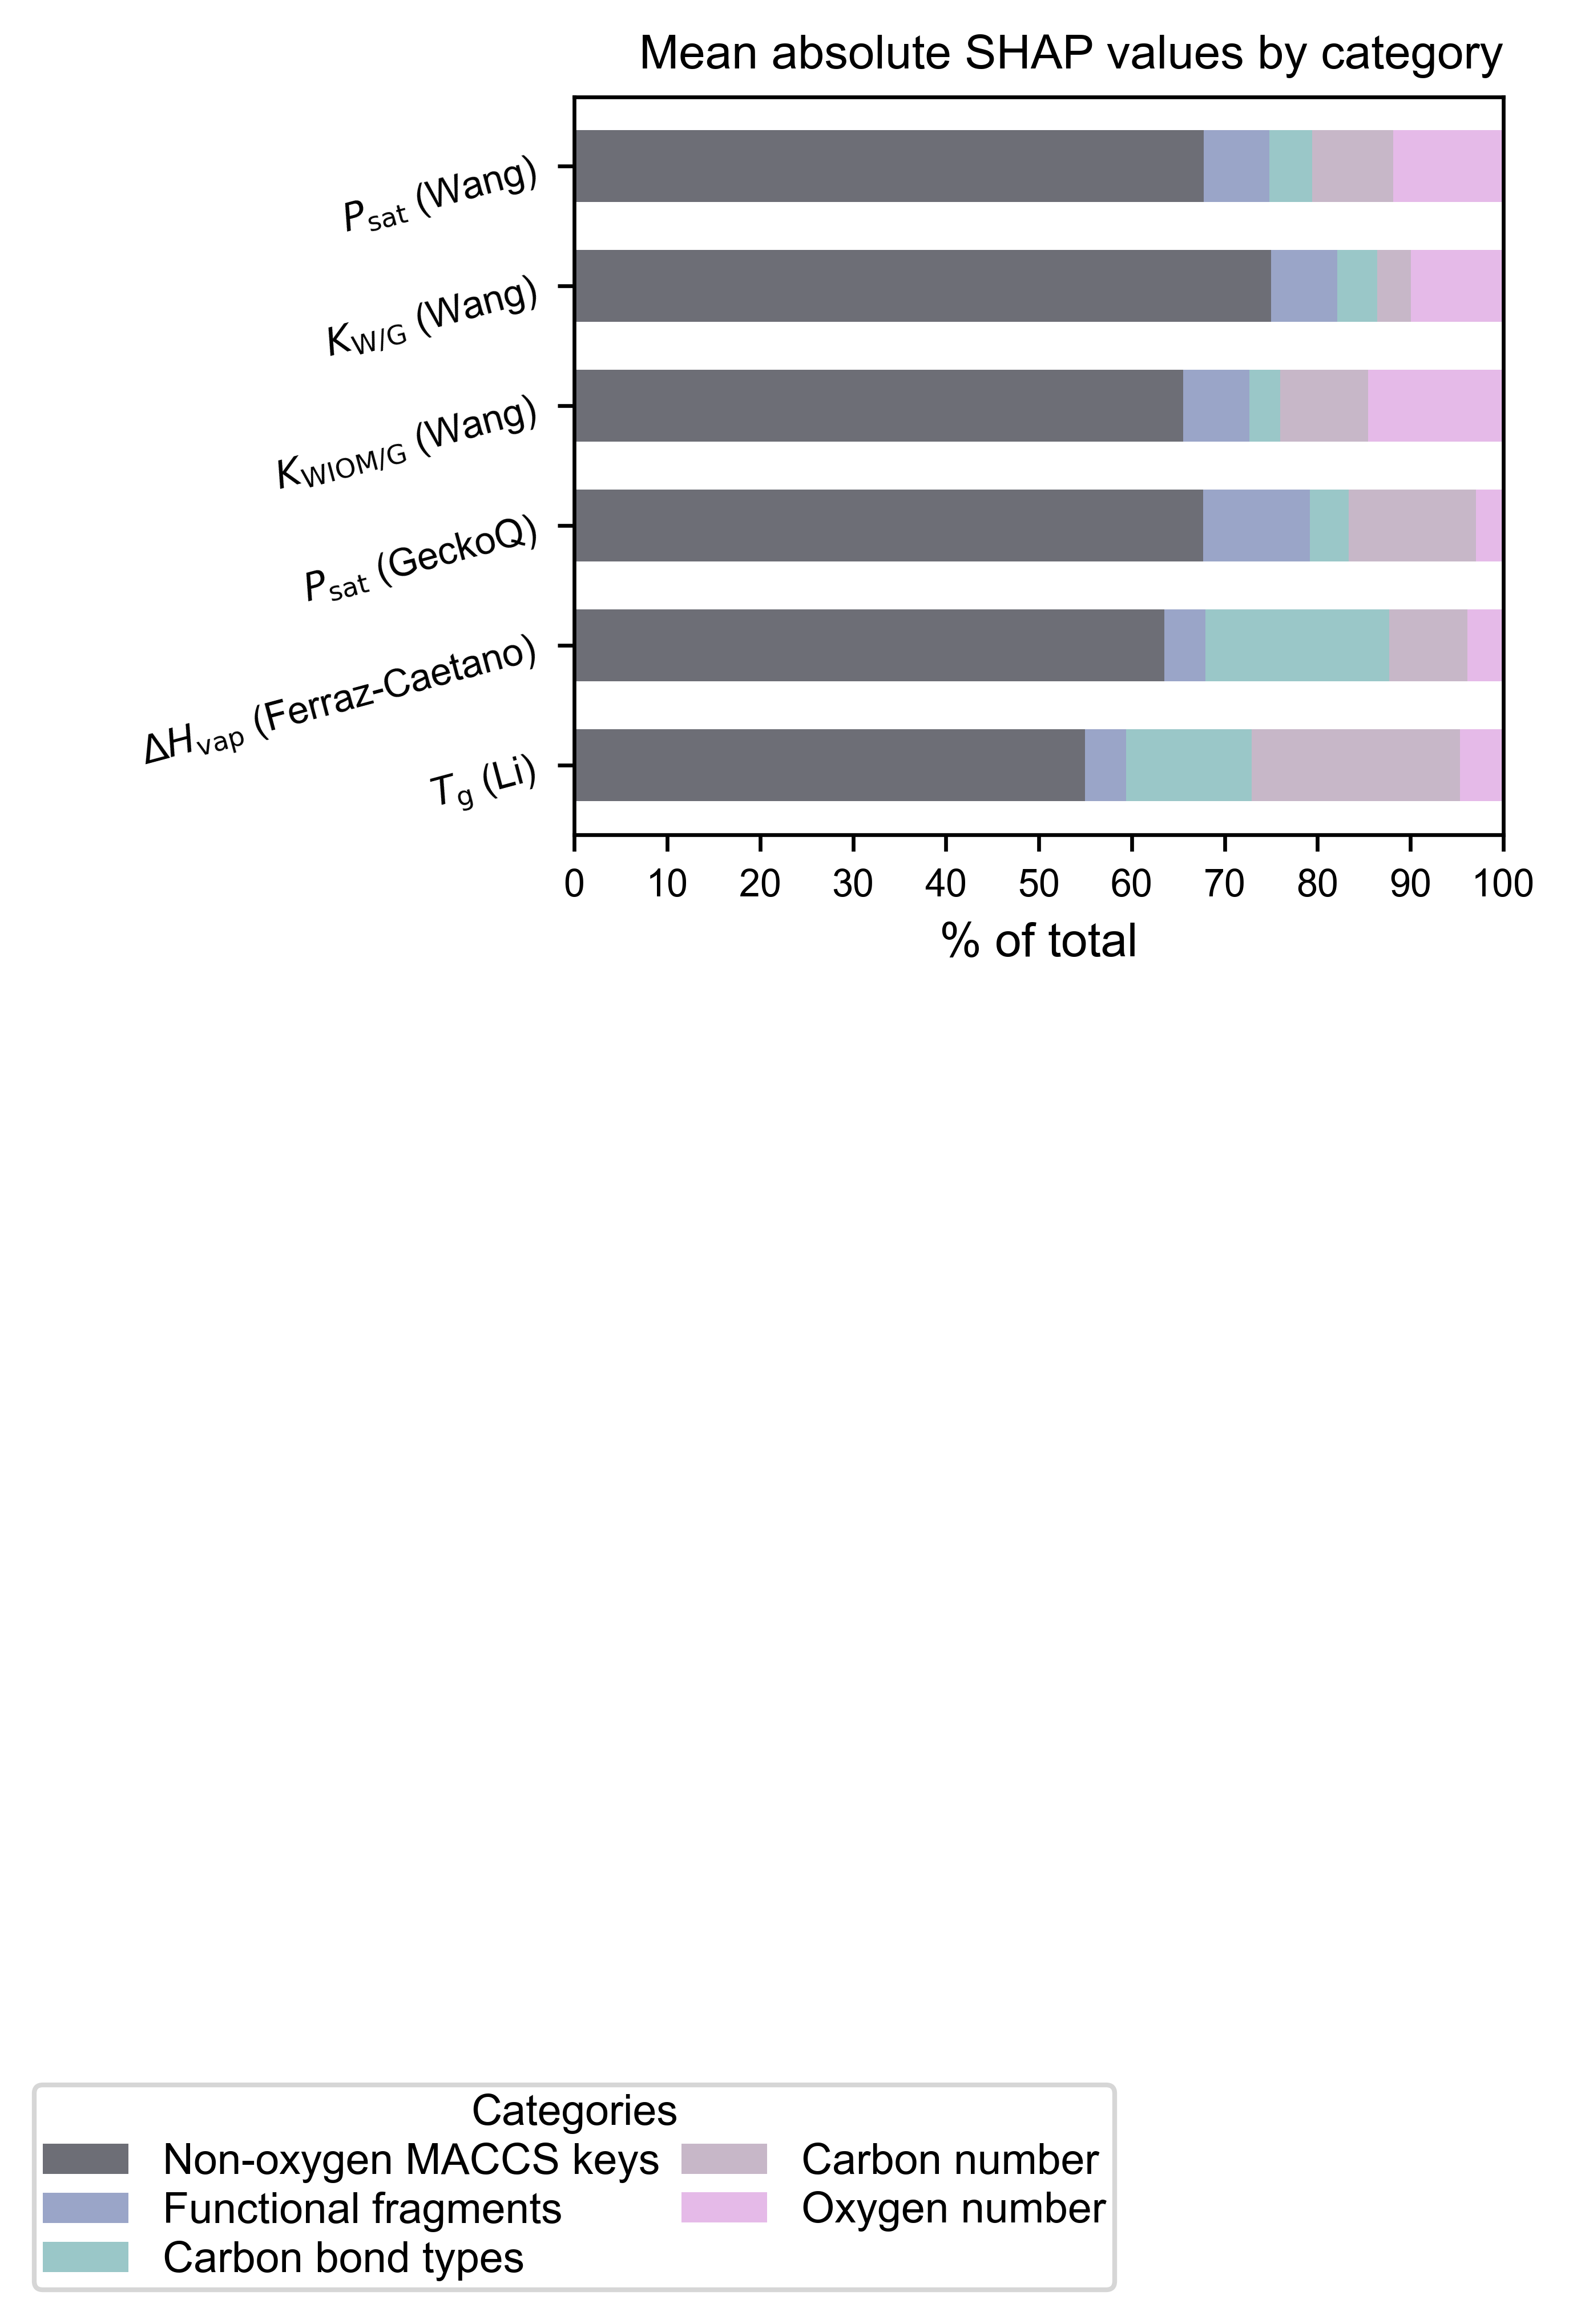

In [383]:
# Set up the plot
fig, ax = plt.subplots(figsize=(252/72, 0.8*252/72))
ytickslabels = [f'{target} ({dataset})' for dataset, target in zip(datasetnames, target_labels)]
print(ytickslabels)
# Initialize the starting position for the bars
left = None
#colors = ['#750817', '#2b2829', '#12711c', '#001c7f', 'Black']

colors = ['#53555e',  # dark gray / charcoal: MACCS
          '#f5bad3',  # soft pink / baby pink: ATMO 
          '#949494',  # light gray '#89bebf': TopFP
          '#bdabbf',  # muted lavender / dusty lilac: ATMOMACCS v2
          '#e1aee4',  # pastel pink-purple / light orchid: ATMOMACCS v1
          '#bdabbf',  # muted lavender / dusty lilac: ATMOMACCS v2
          '#8995BF',  # desaturated periwinkle / dusty indigo: : ATMOMACCS v5
          '#b9e4e4',  # light aqua / pale cyan: : ATMOMACCS v3
          '#89bebf',  # muted teal / soft cyan: ATMOMACCS v4
         ]
colors = ['#53555e', '#8995BF', '#89bebf', '#bdabbf', '#e1aee4']
'''
colors = np.array(colors)
np.random.shuffle(colors)
print(colors)
'''
labels = []
# Plot horizontal stacked bars for each column

for i, row_label in enumerate(df_scaled.index):
    if left is None:
        left = [0] * len(df_scaled.columns)  # Initialize left to start from 0 for the first stack
    ax.barh(df_scaled.columns, df_scaled.loc[row_label], left=left, label=row_label, color=colors[i], height=0.6)
    left += df_scaled.loc[row_label]  # Shift the next stack to the right based on current row
    ax.set_yticklabels(cols[::-1], rotation=15, fontsize = fs-2)
for bar in ax.containers:
    for el in bar:
        el.set_alpha(0.85)

# Add labels and title
ax.set_xlabel('% of total')
xticks = np.linspace(0,1, num=11)
print(xticks)
ax.set_xticks(xticks)
ax.set_xticklabels((100*xticks).astype(int), fontsize=fs-2)
ax.set_xlim([0,1]   )
ax.set_title('Mean absolute SHAP values by category', fontsize=fs, loc ='right')
ax.legend(title='Categories', loc='lower center', ncols=2, bbox_to_anchor=(0,-2), fontsize=fs-1,title_fontsize=fs-1, labelspacing=0.2, columnspacing=0.5, borderpad=0.2)
plt.tight_layout()
plt.gcf().set_dpi(600)
plt.savefig('plots/mean_absolute_shap.png', dpi=600)
plt.show()


In [384]:
df_scaled

,$T_\text{g}$ (Li),$\Delta H_\text{vap}$ (Ferraz-Caetano),$P_{\text{sat}}$ (GeckoQ),$K_{\text{WIOM}/\text{G}}$ (Wang),$K_{\text{W}/\text{G}}$ (Wang),$P_{\text{sat}}$ (Wang)
Non-oxygen MACCS keys,0.549831,0.635161,0.677028,0.655434,0.750332,0.677623
Functional fragments,0.043873,0.044011,0.11475,0.071296,0.071089,0.070706
Carbon bond types,0.135148,0.198265,0.041806,0.033361,0.042718,0.045869
Carbon number,0.224608,0.083727,0.136732,0.09444,0.036642,0.087076
Oxygen number,0.046541,0.038837,0.029684,0.145469,0.099219,0.118727


In [385]:
Wang.mean_absolute_shap_values

,log_p_sat,log_kwg,log_kwiomg
MACCS key 1,0.000000,0.000000,0.000000
MACCS key 2,0.000000,0.000000,0.000000
MACCS key 3,0.000000,0.000000,0.000000
MACCS key 4,0.000000,0.000000,0.000000
MACCS key 5,0.000000,0.000000,0.000000
...,...,...,...
aromatic ring,0.003888,0.002939,0.002946
non-aromatic ring,0.015822,0.036906,0.012575
nitrophenol,0.002691,0.005657,0.002092
carbon number,0.528502,0.176020,0.604533


In [386]:
def normalize_col(df_in, col):
    df = df_in.copy()
    output_col = (df[col] - df[col].min()) / (df[col].max() - df[col].min())
    return output_col

def normalize_vals(vals : pd.Series):
    out_vals = (vals - vals.min()) / (vals.max() - vals.min())
    return out_vals

In [387]:
top_feat_df = pd.DataFrame()
top_feat_df['Wang_log_p_sat'] = normalize_col(Wang.mean_absolute_shap_values, 'log_p_sat')
top_feat_df['Wang_log_kwiomg'] = normalize_col(Wang.mean_absolute_shap_values, 'log_kwiomg')
top_feat_df['Wang_log_kwg'] = normalize_col(Wang.mean_absolute_shap_values, 'log_kwg')
top_feat_df['GeckoQ_log_p_sat'] = normalize_col(geckoq.mean_absolute_shap_values, 'log_p_sat')
top_feat_df['Fc_dvap'] = normalize_col(fc.mean_absolute_shap_values, 'dvap')
top_feat_df['Li_tg'] = normalize_col(li.mean_absolute_shap_values, 'tg')
top_feat_df.mean(axis=1).sort_values(ascending=False).head(10)

carbon number    0.809667
MACCS key 155    0.526446
alkane CH        0.448125
MACCS key 72     0.380630
MACCS key 157    0.352982
MACCS key 139    0.340021
MACCS key 165    0.319338
MACCS key 126    0.300581
MACCS key 131    0.298531
MACCS key 112    0.297803
dtype: float64

In [388]:
with open('../data/Wang/descriptors/ATMOMACCS_DECIMAL_v4_feats.txt', 'r') as file:
    lines = file.readlines()
    feats = [line.replace('\n', '') for line in lines if line != '']
atmo_patts = pd.read_csv('../src/visualization/explained_atmo_patterns_v5.csv')
patts = pd.read_csv('../src/visualization/explained_patterns_v5.csv', index_col='Key ')
patts

,Pattern,rdkit descr.,Question
Key,,,
0,"""""",#extra empty key,empty key
1,"('?', 0)",# ISOTOPE A,How many isotopes are there?
2,"('[#104]', 0)",# limit the above def'n since the RDKit only ...,How many atoms are there that have an atomic ...
3,"('[#32,#33,#34,#50,#51,#52,#82,#83,#84]', 0)","# Group IVa,Va,VIa Rows 4-6",How many atoms are there that belong to groups...
4,"('[Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf,Es,Fm,Md,No,L...",# actinide,How many actinides are there?
...,...,...,...
162,"('a', 0)",# Aromatic,How many aromatic rings are there?
163,"('*1~*~*~*~*~*~1', 0)",# 6M Ring,How many six-membered rings are there?
164,"('[#8]', 0)",# O,How many oxygen atoms are there?


In [389]:
atmo_names = atmo_patts['Name']
maccs_names = [f'MACCS key {i}' for i in range(1,167)]
maccs_questions = patts['Question'].values[1:]
atmo_questions = atmo_patts['Question'].values
maccs_names

['MACCS key 1',
 'MACCS key 2',
 'MACCS key 3',
 'MACCS key 4',
 'MACCS key 5',
 'MACCS key 6',
 'MACCS key 7',
 'MACCS key 8',
 'MACCS key 9',
 'MACCS key 10',
 'MACCS key 11',
 'MACCS key 12',
 'MACCS key 13',
 'MACCS key 14',
 'MACCS key 15',
 'MACCS key 16',
 'MACCS key 17',
 'MACCS key 18',
 'MACCS key 19',
 'MACCS key 20',
 'MACCS key 21',
 'MACCS key 22',
 'MACCS key 23',
 'MACCS key 24',
 'MACCS key 25',
 'MACCS key 26',
 'MACCS key 27',
 'MACCS key 28',
 'MACCS key 29',
 'MACCS key 30',
 'MACCS key 31',
 'MACCS key 32',
 'MACCS key 33',
 'MACCS key 34',
 'MACCS key 35',
 'MACCS key 36',
 'MACCS key 37',
 'MACCS key 38',
 'MACCS key 39',
 'MACCS key 40',
 'MACCS key 41',
 'MACCS key 42',
 'MACCS key 43',
 'MACCS key 44',
 'MACCS key 45',
 'MACCS key 46',
 'MACCS key 47',
 'MACCS key 48',
 'MACCS key 49',
 'MACCS key 50',
 'MACCS key 51',
 'MACCS key 52',
 'MACCS key 53',
 'MACCS key 54',
 'MACCS key 55',
 'MACCS key 56',
 'MACCS key 57',
 'MACCS key 58',
 'MACCS key 59',
 'MACC

In [390]:
out_str = ['keys_to_questions = \{']
for key, question in zip(maccs_names, maccs_questions):
    out_str.append(f'\n  \'{key}\': \'{question}\',')
for key, question in zip(atmo_names, atmo_questions):
    out_str.append(f'\n  \'{key}\': \'{question}\',')
out_str.append('\n \}')

with open('dict_key_to_question.txt', 'w+') as file:
    file.writelines(out_str)

<>:1: SyntaxWarning: invalid escape sequence '\{'
<>:6: SyntaxWarning: invalid escape sequence '\}'
<>:1: SyntaxWarning: invalid escape sequence '\{'
<>:6: SyntaxWarning: invalid escape sequence '\}'
C:\Users\kuuli\AppData\Local\Temp\ipykernel_12476\2781222161.py:1: SyntaxWarning: invalid escape sequence '\{'
  out_str = ['keys_to_questions = \{']
C:\Users\kuuli\AppData\Local\Temp\ipykernel_12476\2781222161.py:6: SyntaxWarning: invalid escape sequence '\}'
  out_str.append('\n \}')


In [391]:
Wang.functional_feature_names[0:5]

[np.str_('amine, primary'),
 np.str_('amine, secondary'),
 np.str_('amine, tertiary'),
 np.str_('hydroxyl (alkyl)'),
 np.str_('carboxylic acid')]

In [392]:
top_feat_df.sum()

Wang_log_p_sat      17.092634
Wang_log_kwiomg     14.525358
Wang_log_kwg        18.018806
GeckoQ_log_p_sat     8.127642
Fc_dvap              4.461164
Li_tg                7.907391
dtype: float64

In [393]:
from sklearn.preprocessing import minmax_scale
dataset_objects = [Wang, geckoq]
datasets = [ds.dataset for ds in dataset_objects]
df = pd.DataFrame()
for ds in dataset_objects:
    ser = ds.mean_absolute_shap_values['log_p_sat']
    ser = normalize_vals(ser)
    ser = ser / ser.sum() 
    ser = ser.sort_values(ascending=False)
    idx = {key : val for key, val in zip(ser.index, range(1,len(ser.index)+1))}
    df[f'{ds.dataset} top #'] = idx
    df[ds.dataset] = ser
# df = df.loc[(df[datasets] != 0).any(axis=1), :]

for dataset in datasets:
    normalized_col = normalize_col(df, dataset)
    df[dataset] = normalized_col / normalized_col.sum() 
df['mean'] = df[datasets].mean(axis=1)
cols = datasets + ['mean'] + [col for col in df.columns if col not in (datasets + ['mean'])]
df = df[cols]
#top5 = df[(df['Wang top #'] <= 5) | (df['GeckoQ top #'] <= 5)]
df.loc[Wang.functional_feature_names].sort_values(by='GeckoQ top #')

,Wang,GeckoQ,mean,Wang top #,GeckoQ top #
non-aromatic ring,0.001751,2.512219e-02,1.343684e-02,86,8
carboxylic acid,0.010328,2.471928e-02,1.752387e-02,30,9
hydroxyl (alkyl),0.021622,1.669172e-02,1.915671e-02,15,17
ether (alicyclic),0.000844,8.912627e-03,4.878167e-03,103,29
ketone,0.008917,8.411375e-03,8.664181e-03,32,32
hydroperoxide,0.012121,8.022353e-03,1.007193e-02,23,35
aldehyde,0.005705,6.762410e-03,6.233527e-03,44,36
peroxide,0.000536,5.329208e-03,2.932446e-03,117,47
"ester, all",0.001348,4.353934e-03,2.850846e-03,95,55
nitrate,0.002269,3.469537e-03,2.869453e-03,80,62


In [394]:
df.sum()

Wang                1.0
GeckoQ              1.0
mean                1.0
Wang top #      20910.0
GeckoQ top #    20910.0
dtype: float64

In [395]:
from sklearn.preprocessing import minmax_scale
datasets = [Wang.dataset, geckoq.dataset]
df = pd.DataFrame()
for ds in datasets:
    ser = top_feat_df[f'{ds}_log_p_sat']
    ser = ser.loc[Wang.functional_feature_names].sort_values(ascending=False)
    idx = {key : val for key, val in zip(ser.index, range(1,len(ser.index)+1))}
    df[f'{ds} top #'] = idx
    df[ds] = ser
df = df.loc[(df[datasets] != 0).any(axis=1), :]
for dataset in datasets:
    normalized_col = normalize_col(df, dataset)
    df[dataset] = normalized_col / normalized_col.sum() 
df['mean'] = df[datasets].mean(axis=1)
cols = datasets + ['mean'] + [col for col in df.columns if col not in (datasets + ['mean'])]
df = df[cols]
df = df.sort_values(by='mean', ascending=False)
df[(df['Wang top #'] <= 5) | (df['GeckoQ top #'] <= 5)]

,Wang,GeckoQ,mean,Wang top #,GeckoQ top #
hydroxyl (alkyl),0.305798,0.145462,0.225630,1,3
carboxylic acid,0.146076,0.215419,0.180748,3,2
non-aromatic ring,0.024772,0.218930,0.121851,8,1
hydroperoxide,0.171436,0.069912,0.120674,2,6
ketone,0.126114,0.073302,0.099708,4,5
aldehyde,0.080681,0.058932,0.069807,5,7
ether (alicyclic),0.011933,0.077670,0.044801,10,4


In [396]:
df.sum()

Wang              1.0
GeckoQ            1.0
mean              1.0
Wang top #      188.0
GeckoQ top #    176.0
dtype: float64